## Сравнение экспериментов

Все атаки тут при **eps=2/255**, каждую модель оценивал по своему:
- для детерминированных моделей обычный **PGD**;
- для шумных моделей испльзовался **EOT-PGD** (т.к обычный PGD завышает результаты).

In [1]:
# ── Собранные результаты (eps=2/255, честные атаки) ──────────────────────
results = [
    dict(method='vanilla',              family='baseline', noise=False, clean=0.881, robust=0.052, attack='PGD'),
    dict(method='siamese frozen',       family='siamese',  noise=False, clean=0.909, robust=0.346, attack='PGD'),
    dict(method='siamese freeze+noise', family='siamese',  noise=True,  clean=0.883, robust=0.445, attack='EOT-PGD'),
    dict(method='siamese soft+noise',   family='siamese',  noise=True,  clean=0.903, robust=0.567, attack='EOT-PGD'),
    dict(method='tile128 soft+noise(1px)',   family='tile',     noise=True,  clean=0.871, robust=0.153, attack='EOT-PGD'),
    dict(method='tile128 soft+noise(1,2,4,8 px)',   family='tile',     noise=True,  clean=0.847, robust=0.425, attack='EOT-PGD'),
]

import pandas as pd
df = pd.DataFrame(results)
df['x_vanilla'] = (df['robust'] / df.loc[df.method == 'vanilla', 'robust'].values[0]).round(2)
df.sort_values('robust', ascending=False).reset_index(drop=True)

,method,family,noise,clean,robust,attack,x_vanilla
0,siamese soft+noise,siamese,True,0.903,0.567,EOT-PGD,10.90
1,siamese freeze+noise,siamese,True,0.883,0.445,EOT-PGD,8.56
2,"tile128 soft+noise(1,2,4,8 px)",tile,True,0.847,0.425,EOT-PGD,8.17
3,siamese frozen,siamese,False,0.909,0.346,PGD,6.65
4,tile128 soft+noise(1px),tile,True,0.871,0.153,EOT-PGD,2.94
5,vanilla,baseline,False,0.881,0.052,PGD,1.00


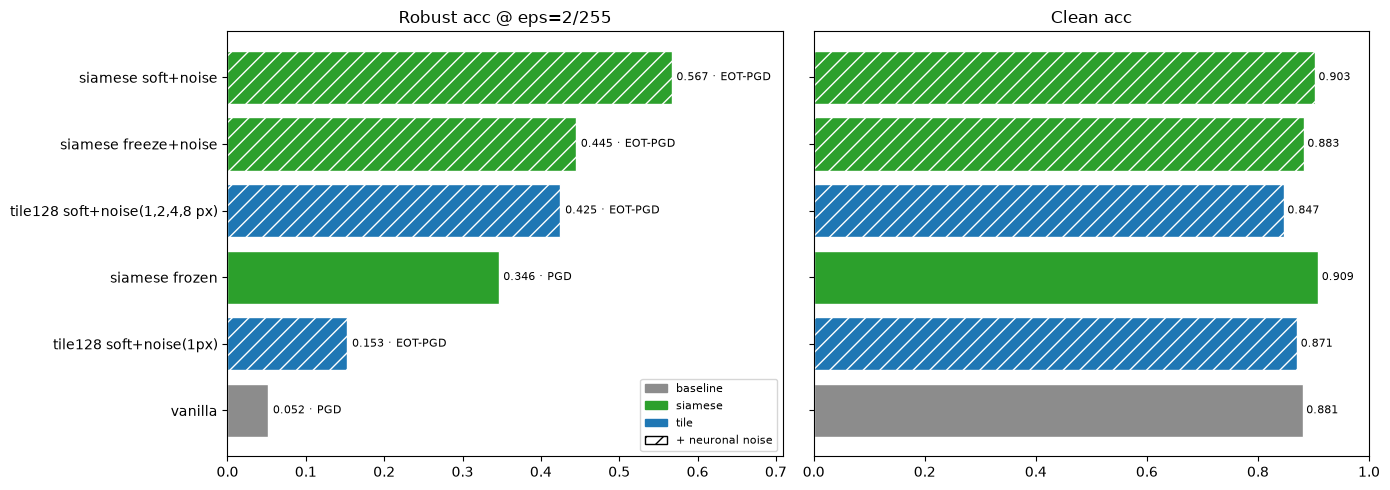

In [2]:
# ── Наглядный график: robust (слева) и clean (справа) ────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

d = pd.DataFrame(results).sort_values('robust').reset_index(drop=True)
fam_colors = {'baseline': '#8c8c8c', 'siamese': '#2ca02c', 'tile': '#1f77b4'}
colors = [fam_colors[f] for f in d.family]
hatches = ['//' if n else '' for n in d.noise]
y = list(range(len(d)))

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax[0].barh(y, d.robust, color=colors, hatch=hatches, edgecolor='white')
ax[0].set_yticks(y); ax[0].set_yticklabels(d.method)
ax[0].set_title('Robust acc @ eps=2/255')
ax[0].set_xlim(0, max(d.robust) * 1.25)
for i, (r, a) in enumerate(zip(d.robust, d.attack)):
    ax[0].text(r + 0.006, i, f'{r:.3f} · {a}', va='center', fontsize=8)

ax[1].barh(y, d.clean, color=colors, hatch=hatches, edgecolor='white')
ax[1].set_title('Clean acc')
ax[1].set_xlim(0, 1.0)
for i, c in enumerate(d.clean):
    ax[1].text(c + 0.006, i, f'{c:.3f}', va='center', fontsize=8)

legend = [Patch(color=v, label=k) for k, v in fam_colors.items()]
legend += [Patch(facecolor='white', edgecolor='black', hatch='//', label='+ neuronal noise')]
ax[0].legend(handles=legend, fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

### Новый эксперимент

In [3]:
import os
import sys

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

In [ ]:
from src.train_tile import run_training

res = run_training(
    tile_dir='output_solo_exp/dataset_tile', tile_csv='output_solo_exp/labels_tile.csv',
    noise_sigma=0.5, soft_delta=0.01,
    robust_batches=8, eot_k=5,      # быстрый замер
    name='tile128 φ_a∈{1,2,4,8} soft+noise(BN)',
)
res

Device: cuda | name=tile128 φ_a∈{1,2,4,8} soft+noise(BN) noise=0.5 δ=0.01 pretrain=True


[pretrain 1/30] MSE(log₂ψ) = 1.5810


[pretrain 2/30] MSE(log₂ψ) = 0.7184


[pretrain 3/30] MSE(log₂ψ) = 0.5733


[pretrain 4/30] MSE(log₂ψ) = 0.5219


...

Epoch 08 | train_loss=0.3590 train_acc=0.8682 | test_acc=0.8191


Epoch 09 | train_loss=0.2649 train_acc=0.9121 | test_acc=0.8425


Epoch 10 | train_loss=0.2287 train_acc=0.9203 | test_acc=0.8506



── Итог [tile128 φ_a∈{1,2,4,8} soft+noise(BN)] (eps=2/255) ──
clean = 0.8502 | PGD = 0.4658 | EOT-PGD(k=5) = 0.4268 ← честное


{'name': 'tile128 φ_a∈{1,2,4,8} soft+noise(BN)',
 'clean': 0.85025,
 'pgd': 0.4658203125,
 'eot': 0.4267578125,
 'honest': 0.4267578125,
 'attack': 'EOT-PGD',
 'noise_sigma': 0.5,
 'soft_delta': 0.01,
 'eps': 0.00784313725490196}

In [6]:
# дописываю результат прогона в таблицу
results.append(dict(
    method=res['name'],
    family='tile',
    noise=res['noise_sigma'] > 0,
    clean=round(res['clean'], 3),
    robust=round(res['honest'], 3),
    attack=res['attack'],
))
pd.DataFrame(results).sort_values('robust', ascending=False).reset_index(drop=True)

,method,family,noise,clean,robust,attack
0,siamese soft+noise,siamese,True,0.903,0.567,EOT-PGD
1,siamese freeze+noise,siamese,True,0.883,0.445,EOT-PGD
2,"tile128 φ_a∈{1,2,4,8} soft+noise(BN)",tile,True,0.850,0.427,EOT-PGD
3,"tile128 soft+noise(1,2,4,8 px)",tile,True,0.847,0.425,EOT-PGD
4,siamese frozen,siamese,False,0.909,0.346,PGD
5,tile128 soft+noise(1px),tile,True,0.871,0.153,EOT-PGD
6,vanilla,baseline,False,0.881,0.052,PGD


In [ ]:
from src.train_tile import run_training

res = run_training(
    tile_dir='output_solo_exp/dataset_tile', tile_csv='output_solo_exp/labels_tile.csv',
    noise_sigma=0.5, soft_delta=0.01,
    robust_batches=8, eot_k=5,      # быстрый замер
    name='tile128 φ_a∈{1,2,4,8} soft+noise(BN2)',
)
res

Device: cuda | name=tile128 φ_a∈{1,2,4,8} soft+noise(BN2) noise=0.5 δ=0.01 pretrain=True


[pretrain 1/30] MSE(log₂ψ) = 1.5854


[pretrain 2/30] MSE(log₂ψ) = 0.7295


[pretrain 3/30] MSE(log₂ψ) = 0.5769


[pretrain 4/30] MSE(log₂ψ) = 0.5140


...

Epoch 08 | train_loss=0.3807 train_acc=0.8676 | test_acc=0.8237


Epoch 09 | train_loss=0.2899 train_acc=0.8978 | test_acc=0.8370


Epoch 10 | train_loss=0.2513 train_acc=0.9135 | test_acc=0.8427



── Итог [tile128 φ_a∈{1,2,4,8} soft+noise(BN2)] (eps=2/255) ──
clean = 0.8417 | PGD = 0.4570 | EOT-PGD(k=5) = 0.4092 ← честное


{'name': 'tile128 φ_a∈{1,2,4,8} soft+noise(BN2)',
 'clean': 0.84175,
 'pgd': 0.45703125,
 'eot': 0.4091796875,
 'honest': 0.4091796875,
 'attack': 'EOT-PGD',
 'noise_sigma': 0.5,
 'soft_delta': 0.01,
 'eps': 0.00784313725490196}

In [8]:
# дописываю результат прогона в таблицу
results.append(dict(
    method=res['name'],
    family='tile',
    noise=res['noise_sigma'] > 0,
    clean=round(res['clean'], 3),
    robust=round(res['honest'], 3),
    attack=res['attack'],
))
pd.DataFrame(results).sort_values('robust', ascending=False).reset_index(drop=True)

,method,family,noise,clean,robust,attack
0,siamese soft+noise,siamese,True,0.903,0.567,EOT-PGD
1,siamese freeze+noise,siamese,True,0.883,0.445,EOT-PGD
2,"tile128 φ_a∈{1,2,4,8} soft+noise(BN)",tile,True,0.850,0.427,EOT-PGD
3,"tile128 soft+noise(1,2,4,8 px)",tile,True,0.847,0.425,EOT-PGD
4,"tile128 φ_a∈{1,2,4,8} soft+noise(BN2)",tile,True,0.842,0.409,EOT-PGD
5,siamese frozen,siamese,False,0.909,0.346,PGD
6,tile128 soft+noise(1px),tile,True,0.871,0.153,EOT-PGD
7,vanilla,baseline,False,0.881,0.052,PGD


## Black-box атаки

Две рассматриваемые black-box атаки:
- **Square** — атакующий видит только выход (score-based).
- **Transfer** — атакуем на суррогатной модели, переносим результат(использовал frozen чекпоинт).

In [ ]:
import torch
from scripts.eval_blackbox import load_model, get_loader01, square_acc, transfer_acc
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ld = get_loader01(n=1000)

surrogate = load_model('models/ResNetSIMv2_frozen_best.pth', noise_sigma=0.0, device=device, arch='siamese')

targets = [
    ('siamese soft+noise', 'models/ResNetSIM_soft_noisy_best.pth', 'siamese', 0.5),
    ('siamese frozen', 'models/ResNetSIMv2_frozen_best.pth','siamese', 0.0),
    ('tile128 soft+noise', 'output/tile_cls_noisy.pt', 'tile', 0.5),
]

bb = []
for name, ckpt, arch, ns in targets:
    tgt = load_model(ckpt, noise_sigma=ns, device=device, arch=arch)
    for eps in [2/255, 4/255]:
        sq = square_acc(tgt, ld, eps, device, n_queries=2000)
        tr = transfer_acc(tgt, surrogate, ld, eps, device, steps=20)
        bb.append(dict(model=name, eps=f'{eps*255:.0f}/255', square=round(sq, 3), transfer=round(tr, 3)))
        print(f'{name:22s} eps={eps*255:.0f}/255  Square={sq:.3f}  Transfer={tr:.3f}')
pd.DataFrame(bb)

siamese soft+noise     eps=2/255  Square=0.897  Transfer=0.825
siamese soft+noise     eps=4/255  Square=0.891  Transfer=0.725
siamese frozen         eps=2/255  Square=0.778  Transfer=0.346
siamese frozen         eps=4/255  Square=0.575  Transfer=0.059
tile128 soft+noise     eps=2/255  Square=0.914  Transfer=0.845
tile128 soft+noise     eps=4/255  Square=0.919  Transfer=0.711


,model,eps,square,transfer
0,siamese soft+noise,2/255,0.897,0.825
1,siamese soft+noise,4/255,0.891,0.725
2,siamese frozen,2/255,0.778,0.346
3,siamese frozen,4/255,0.575,0.059
4,tile128 soft+noise,2/255,0.914,0.845
5,tile128 soft+noise,4/255,0.919,0.711
